In [60]:
import os
import sys

# VS Code Jupyter kernels do not run conda activate.d scripts, so the
# geospatial library data paths must be set explicitly before importing
# geopandas. Without this, to_crs can fail to locate the PROJ database.
os.environ.setdefault("PROJ_LIB", os.path.join(sys.prefix, "share", "proj"))
os.environ.setdefault("GDAL_DATA", os.path.join(sys.prefix, "share", "gdal"))

from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
CURATED_DIR = PROJECT_ROOT / "data" / "curated"

# Boundaries carry the geometry, so the geopackage is read rather than the
# parquet that downstream members use.
sa2 = gpd.read_file(CURATED_DIR / "sa2_features.gpkg", engine="pyogrio")
schools = pd.read_parquet(RAW_DIR / "vic_school_points.parquet")
stations = pd.read_parquet(RAW_DIR / "vic_train_stations.parquet")

assert len(sa2) == 524, f"Expected 524 SA2s, got {len(sa2)}"
assert len(schools) == 2293, f"Expected 2293 schools, got {len(schools)}"
assert len(stations) == 320, f"Expected 320 stations, got {len(stations)}"

print(f"SA2 boundaries: {len(sa2)}, CRS {sa2.crs}")
print(f"Schools: {len(schools)}")
print(f"Stations: {len(stations)}")

SA2 boundaries: 524, CRS EPSG:7844
Schools: 2293
Stations: 320


In [61]:
# Distances must be computed in a projected CRS. In a geographic CRS the units
# are degrees, and a degree of longitude shrinks with latitude, so Euclidean
# distance on raw coordinates is wrong by a varying amount across the state.
# EPSG 7855 is GDA2020 MGA Zone 55, which covers Victoria, with metre units.
PROJECTED_CRS = "EPSG:7855"
GEOGRAPHIC_CRS = "EPSG:4326"

# Melbourne CBD reference point, taken as Flinders Street Station, the
# conventional origin for measuring distance to the city.
CBD_LAT, CBD_LON = -37.8183, 144.9671

cbd = gpd.GeoSeries(
    gpd.points_from_xy([CBD_LON], [CBD_LAT]),
    crs=GEOGRAPHIC_CRS,
).to_crs(PROJECTED_CRS)

print(f"CBD reference in {PROJECTED_CRS}: {cbd.iloc[0]}")

CBD reference in EPSG:7855: POINT (321067.9288511081 5812397.829723075)


In [62]:
def to_projected_gdf(df, lon_col="longitude", lat_col="latitude"):
    """
    Build a projected GeoDataFrame from a table of decimal degree coordinates.

    Source coordinates are declared as EPSG 4326 and then reprojected, rather
    than being assigned the projected CRS directly. Assigning the wrong CRS
    does not raise, it simply places every point in the wrong location.
    """
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
        crs=GEOGRAPHIC_CRS,
    )
    return gdf.to_crs(PROJECTED_CRS)


schools_proj = to_projected_gdf(schools)
stations_proj = to_projected_gdf(stations)
sa2_proj = sa2.to_crs(PROJECTED_CRS)

assert schools_proj.crs == stations_proj.crs == sa2_proj.crs, "CRS mismatch"
print(f"All layers projected to {schools_proj.crs.name}")

All layers projected to GDA2020 / MGA zone 55


In [63]:
def make_test_properties(n=500, seed=42):
    """
    Build a stand in for the scraped property table.

    Real station coordinates are used as the base rather than uniform random
    points, because rental listings cluster where people live and stations sit
    in the same places. A uniform sample over the state bounding box would put
    most test points in farmland, where the nearest station is tens of
    kilometres away, and would hide any problem that only appears in dense
    urban areas.

    A random offset of up to roughly two kilometres is added so the points are
    near stations rather than exactly on them.
    """
    rng = np.random.default_rng(seed)
    base = stations.sample(n=n, replace=True, random_state=seed).reset_index(drop=True)

    # One degree of latitude is about 111 km. At Victorian latitudes one degree
    # of longitude is about 88 km, so the longitude offset is scaled to keep
    # the displacement roughly circular on the ground.
    lat_offset = rng.normal(0, 0.018, n)
    lon_offset = rng.normal(0, 0.023, n)

    return pd.DataFrame({
        "property_id": [f"test_{i:05d}" for i in range(n)],
        "latitude": base["latitude"] + lat_offset,
        "longitude": base["longitude"] + lon_offset,
    })


test_properties = make_test_properties()
print(f"Test properties: {len(test_properties)}")
print(test_properties.head())
print(f"\nLatitude range:  {test_properties['latitude'].min():.4f} to {test_properties['latitude'].max():.4f}")
print(f"Longitude range: {test_properties['longitude'].min():.4f} to {test_properties['longitude'].max():.4f}")

Test properties: 500
  property_id   latitude   longitude
0  test_00000 -38.159348  145.964026
1  test_00001 -37.801937  145.012996
2  test_00002 -36.092337  146.854718
3  test_00003 -37.712331  144.616074
4  test_00004 -37.856945  144.954714

Latitude range:  -38.4237 to -35.3565
Longitude range: 142.4231 to 146.9116


In [64]:
properties_proj = to_projected_gdf(test_properties)

# Point in polygon. Suburb names are never used for this, because a suburb can
# span several SA2s and an SA2 can contain several suburbs, so name matching
# produces confident but wrong assignments.
properties_sa2 = gpd.sjoin(
    properties_proj,
    sa2_proj[["sa2_code_2021", "sa2_name_2021", "geometry"]],
    how="left",
    predicate="within",
)

# A left join cannot lose rows, but overlapping polygons would duplicate them.
# ABS boundaries are exhaustive and non overlapping, so the count must hold.
assert len(properties_sa2) == len(properties_proj), \
    f"Spatial join changed row count from {len(properties_proj)} to {len(properties_sa2)}"

unmatched = properties_sa2["sa2_code_2021"].isna()
print(f"Properties matched to an SA2: {(~unmatched).sum()}")
print(f"Properties outside all Victorian SA2s: {unmatched.sum()}")

if unmatched.any():
    print("\nUnmatched points, expected where the random offset crossed the")
    print("state border or landed in water:")
    print(
        properties_sa2[unmatched][["property_id", "longitude", "latitude"]]
        .head(10).to_string(index=False)
    )

Properties matched to an SA2: 470
Properties outside all Victorian SA2s: 30

Unmatched points, expected where the random offset crossed the
state border or landed in water:
property_id  longitude   latitude
 test_00004 144.954714 -37.856945
 test_00023 145.083258 -38.009364
 test_00030 145.117842 -38.104440
 test_00036 144.882092 -37.866033
 test_00067 144.874080 -37.865873
 test_00076 144.919830 -37.865241
 test_00159 145.100136 -38.057865
 test_00161 144.894080 -37.877036
 test_00169 144.983234 -37.890453
 test_00211 144.905236 -37.881425


In [65]:
# Take one clearly urban unmatched point and work out why it failed
probe = properties_sa2[unmatched].iloc[0]
probe_point = properties_proj.loc[properties_proj["property_id"] == probe["property_id"], "geometry"].iloc[0]
print(f"Probe point: {probe['property_id']} at {probe['longitude']:.5f}, {probe['latitude']:.5f}")

# Which SA2 is nearest, and how far away is it
distances = sa2_proj.geometry.distance(probe_point)
nearest_idx = distances.idxmin()
print(f"Nearest SA2: {sa2_proj.loc[nearest_idx, 'sa2_name_2021']}")
print(f"Distance to it: {distances.min():.6f} metres")

# Does any polygon actually contain it under a looser predicate
contains = sa2_proj[sa2_proj.geometry.contains(probe_point)]
intersects = sa2_proj[sa2_proj.geometry.intersects(probe_point)]
print(f"\nPolygons containing the point: {len(contains)}")
print(f"Polygons intersecting the point: {len(intersects)}")

# Geometry validity across the whole layer
invalid = ~sa2_proj.geometry.is_valid
print(f"\nInvalid geometries in the projected layer: {invalid.sum()}")
if invalid.any():
    print(sa2_proj[invalid][["sa2_code_2021", "sa2_name_2021"]].to_string(index=False))

Probe point: test_00004 at 144.95471, -37.85694
Nearest SA2: Albert Park
Distance to it: 538.168154 metres

Polygons containing the point: 0
Polygons intersecting the point: 0

Invalid geometries in the projected layer: 2
sa2_code_2021                          sa2_name_2021
    297979799 Migratory - Offshore - Shipping (Vic.)
    299999499                No usual address (Vic.)


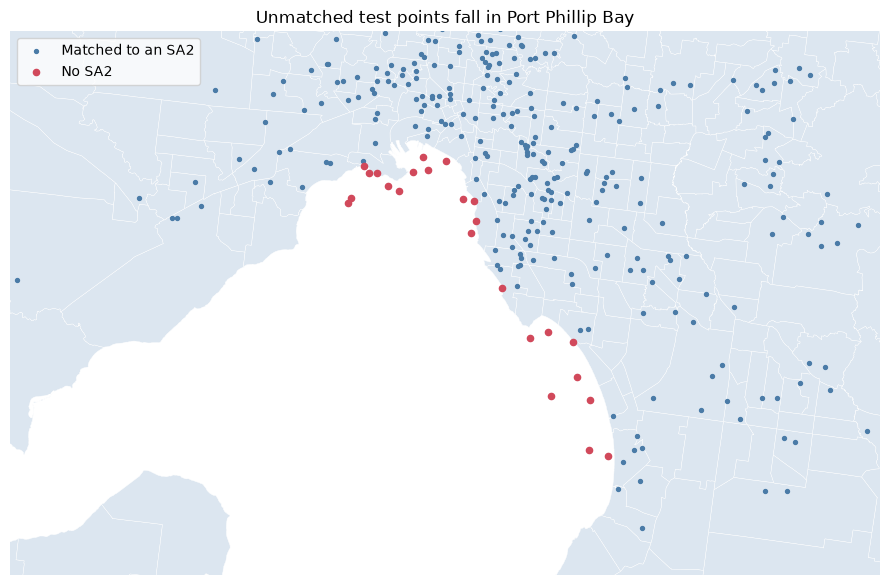

In [66]:
fig, ax = plt.subplots(figsize=(9, 9))

# Zoom to the Port Phillip Bay area where the unmatched points cluster
bay = sa2_proj.cx[280000:360000, 5770000:5820000]
bay.plot(ax=ax, color="#dce6f0", edgecolor="white", linewidth=0.3)

matched_pts = properties_proj[~unmatched.values]
unmatched_pts = properties_proj[unmatched.values]

matched_pts.plot(ax=ax, color="#4a7ba7", markersize=8, label="Matched to an SA2")
unmatched_pts.plot(ax=ax, color="#d1495b", markersize=20, label="No SA2")

ax.set_xlim(280000, 360000)
ax.set_ylim(5770000, 5820000)
ax.set_title("Unmatched test points fall in Port Phillip Bay")
ax.legend()
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [67]:
# The unmatched points are an artefact of the test data generator, which
# perturbs station coordinates by up to two kilometres. Bayside stations such
# as Mordialloc, Chelsea and Port Melbourne sit on the shoreline, so a random
# offset pushes some points into Port Phillip Bay. Real listings will not be
# in the water, so this rate should approach zero on scraped data.
#
# The join is left as is. Points outside every SA2 are reported rather than
# snapped to the nearest polygon, because snapping would fabricate a location
# and hide genuine coordinate errors in the real data.
properties_sa2 = properties_sa2.drop(columns=["index_right"])
properties_sa2["in_victoria"] = properties_sa2["sa2_code_2021"].notna()

print(f"Unmatched rate on test data: {(~properties_sa2['in_victoria']).mean():.1%}")
print("Expected to be near zero on scraped listings.")

# The two special purpose SA2s report as invalid geometry because their
# geometry is empty. They were flagged during the external data build and are
# skipped by both sjoin and distance, so no action is needed here.

Unmatched rate on test data: 6.0%
Expected to be near zero on scraped listings.


In [68]:
from sklearn.neighbors import BallTree


def nearest_distance(source_gdf, target_gdf, k=1):
    """
    Straight line distance in metres from each source point to its k nearest
    targets, using a BallTree over projected coordinates.

    Euclidean distance is valid here because both layers are in EPSG 7855,
    where the unit is the metre. The same computation on raw latitude and
    longitude would be wrong, since a degree of longitude is shorter than a
    degree of latitude at Victorian latitudes.

    Returns two arrays of shape n_source by k. The first holds distances in
    metres and the second holds positional indices into target_gdf, so the
    caller looks up whatever target attributes it needs from those indices.
    """
    src_xy = np.column_stack([source_gdf.geometry.x, source_gdf.geometry.y])
    tgt_xy = np.column_stack([target_gdf.geometry.x, target_gdf.geometry.y])

    tree = BallTree(tgt_xy, metric="euclidean")
    dist, idx = tree.query(src_xy, k=k)

    return dist, idx


# Nearest station
station_dist, station_idx = nearest_distance(properties_proj, stations_proj)
properties_sa2["straight_km_to_nearest_station"] = station_dist[:, 0] / 1000
properties_sa2["nearest_station_name"] = (
    stations_proj["stop_name"].to_numpy()[station_idx[:, 0]]
)

# Nearest school
school_dist, school_idx = nearest_distance(properties_proj, schools_proj)
properties_sa2["straight_km_to_nearest_school"] = school_dist[:, 0] / 1000
properties_sa2["nearest_school_name"] = (
    schools_proj["School_Name"].to_numpy()[school_idx[:, 0]]
)

print(properties_sa2[[
    "straight_km_to_nearest_station", "straight_km_to_nearest_school"
]].describe().round(3))

       straight_km_to_nearest_station  straight_km_to_nearest_school
count                         500.000                        500.000
mean                            1.635                          1.142
std                             1.186                          1.101
min                             0.104                          0.042
25%                             0.728                          0.459
50%                             1.278                          0.730
75%                             2.295                          1.355
max                             7.400                          6.101


In [69]:
def count_within_radius(source_gdf, target_gdf, radii_m):
    """
    Count target points within each given radius of every source point.

    A radius count complements a nearest distance. Two properties can both sit
    400 metres from a school, but one may have six schools within two
    kilometres while the other has one. Families weigh choice as well as
    proximity, so both are kept.
    """
    src_xy = np.column_stack([source_gdf.geometry.x, source_gdf.geometry.y])
    tgt_xy = np.column_stack([target_gdf.geometry.x, target_gdf.geometry.y])
    tree = BallTree(tgt_xy, metric="euclidean")

    return {r: tree.query_radius(src_xy, r=r, count_only=True) for r in radii_m}


school_counts = count_within_radius(properties_proj, schools_proj, [1000, 2000])
properties_sa2["n_schools_within_1km"] = school_counts[1000]
properties_sa2["n_schools_within_2km"] = school_counts[2000]

station_counts = count_within_radius(properties_proj, stations_proj, [1000, 2000])
properties_sa2["n_stations_within_1km"] = station_counts[1000]
properties_sa2["n_stations_within_2km"] = station_counts[2000]

count_cols = [
    "n_schools_within_1km", "n_schools_within_2km",
    "n_stations_within_1km", "n_stations_within_2km",
]
print(properties_sa2[count_cols].describe().round(2))

# A property can be close to one school yet have few others nearby, so the
# two measures should not be redundant.
corr = properties_sa2[
    ["straight_km_to_nearest_school", "n_schools_within_2km"]
].corr().iloc[0, 1]
print(f"\nCorrelation between nearest school distance and school count within 2km: {corr:.3f}")

       n_schools_within_1km  n_schools_within_2km  n_stations_within_1km  \
count                500.00                500.00                 500.00   
mean                   1.67                  6.42                   0.59   
std                    1.69                  5.08                   0.87   
min                    0.00                  0.00                   0.00   
25%                    0.00                  2.00                   0.00   
50%                    1.00                  6.00                   0.00   
75%                    3.00                 10.00                   1.00   
max                    8.00                 22.00                   5.00   

       n_stations_within_2km  
count                 500.00  
mean                    2.08  
std                     2.39  
min                     0.00  
25%                     0.00  
50%                     1.00  
75%                     3.00  
max                    12.00  

Correlation between nearest school 

In [70]:
from dotenv import load_dotenv

load_dotenv(PROJECT_ROOT / ".env")
ORS_API_KEY = os.environ.get("ORS_API_KEY")

# Never print the key itself. Confirming its length and prefix is enough to
# know it loaded, without writing the credential into the notebook output,
# which would then be committed along with the notebook.
if ORS_API_KEY and ORS_API_KEY != "replace_with_your_key":
    print(f"Key loaded, length {len(ORS_API_KEY)}, starts with {ORS_API_KEY[:6]}")
else:
    print("Key not loaded. Check that .env exists and the value was replaced.")

Key loaded, length 120, starts with eyJvcm


In [71]:
import json
import time

import requests

# The api.openrouteservice.org host is being retired. HeiGIT now serves all
# its APIs under the pattern api.heigit.org/<service>/<version>, so the
# service name must appear in the path.
ORS_BASE_URL = "https://api.heigit.org/openrouteservice/v2"

# Free tier limits observed on the account dashboard. Matrix has a much lower
# daily allowance than Directions, but one matrix call covers many origin and
# destination pairs, so it is far more efficient per pair.
ORS_LIMITS = {
    "matrix": {"daily": 500, "per_minute": 40},
    "directions": {"daily": 2000, "per_minute": 40},
}

CACHE_DIR = PROJECT_ROOT / "cache"
CACHE_DIR.mkdir(exist_ok=True)
MATRIX_CACHE_PATH = CACHE_DIR / "ors_matrix_cache.json"


def load_cache(path):
    """
    Load a cached response store, returning an empty dict if none exists.

    Caching matters more here than in most projects. The free tier allows 500
    matrix calls per day, so an unguarded rerun of this notebook could exhaust
    a day of quota and block work until the reset.
    """
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return {}


def save_cache(cache, path):
    with open(path, "w") as f:
        json.dump(cache, f)


matrix_cache = load_cache(MATRIX_CACHE_PATH)
print(f"Matrix cache entries loaded: {len(matrix_cache)}")
print(f"Cache file: {MATRIX_CACHE_PATH}")

Matrix cache entries loaded: 3
Cache file: /Users/all_for_alin/Downloads/26-s2-ADS/project2/cache/ors_matrix_cache.json


In [72]:
def ors_matrix(origins, destinations, profile="driving-car", metrics=("distance", "duration")):
    """
    Request a distance and duration matrix from OpenRouteService.

    Coordinates are given as lists of [longitude, latitude] pairs, which is the
    order ORS expects. Passing latitude first produces a valid looking response
    for points somewhere else entirely, so the order is asserted rather than
    assumed.

    Responses are cached on a key built from the rounded coordinates, so a
    rerun of the notebook costs no quota. Rounding to five decimal places is
    about one metre, well below the precision of a street address.
    """
    assert all(-180 <= lon <= 180 and -90 <= lat <= 90 for lon, lat in origins), \
        "Origins must be [longitude, latitude], not [latitude, longitude]"
    assert all(-180 <= lon <= 180 and -90 <= lat <= 90 for lon, lat in destinations), \
        "Destinations must be [longitude, latitude], not [latitude, longitude]"

    locations = [[round(c, 5) for c in pt] for pt in origins + destinations]
    sources = list(range(len(origins)))
    targets = list(range(len(origins), len(locations)))

    cache_key = json.dumps(
        {"loc": locations, "src": sources, "tgt": targets, "profile": profile},
        sort_keys=True,
    )
    if cache_key in matrix_cache:
        return matrix_cache[cache_key], True

    response = requests.post(
        f"{ORS_BASE_URL}/matrix/{profile}",
        json={
            "locations": locations,
            "sources": sources,
            "destinations": targets,
            "metrics": list(metrics),
        },
        headers={
            "Authorization": ORS_API_KEY,
            "Content-Type": "application/json",
        },
        timeout=60,
    )

    if response.status_code == 429:
        raise RuntimeError("Per minute rate limit hit. Wait 60 seconds and retry.")
    if response.status_code == 403:
        raise RuntimeError("Daily quota exhausted. The allowance resets at midnight UTC.")
    response.raise_for_status()

    result = response.json()
    matrix_cache[cache_key] = result
    save_cache(matrix_cache, MATRIX_CACHE_PATH)
    return result, False

In [73]:
# Single call test: Flinders Street to Melbourne Airport, a route with a well
# known road distance of roughly 23 kilometres.
test_result, from_cache = ors_matrix(
    origins=[[144.9671, -37.8183]],
    destinations=[[144.8410, -37.6690]],
)

km = test_result["distances"][0][0] / 1000
minutes = test_result["durations"][0][0] / 60
print(f"Flinders Street to Melbourne Airport")
print(f"Route distance: {km:.1f} km")
print(f"Route duration: {minutes:.1f} minutes")
print(f"Served from cache: {from_cache}")

Flinders Street to Melbourne Airport
Route distance: 27.5 km
Route duration: 35.8 minutes
Served from cache: True


In [74]:
# Stage one: shortlist candidates locally. Straight line distance is a good
# but imperfect proxy for route distance, since a river, freeway or rail line
# can put a station that is close in a straight line far away by road. Taking
# the nearest five candidates rather than one makes it very unlikely that the
# true nearest station by road is missed.
N_CANDIDATES = 5

cand_dist, cand_idx = nearest_distance(
    properties_proj, stations_proj, k=N_CANDIDATES
)

print(f"Shortlisted {N_CANDIDATES} candidate stations per property")
print(f"Straight line distance to the nearest candidate, km:")
print(pd.Series(cand_dist[:, 0] / 1000).describe().round(3))
print(f"\nTo the fifth candidate, km:")
print(pd.Series(cand_dist[:, 4] / 1000).describe().round(3))

# The set of stations that actually need to be queried is much smaller than
# the full network, since properties cluster around the same stations.
needed_stations = np.unique(cand_idx)
print(f"\nDistinct stations appearing in any shortlist: {len(needed_stations)} of {len(stations_proj)}")

Shortlisted 5 candidate stations per property
Straight line distance to the nearest candidate, km:
count    500.000
mean       1.635
std        1.186
min        0.104
25%        0.728
50%        1.278
75%        2.295
max        7.400
dtype: float64

To the fifth candidate, km:
count    500.000
mean      11.093
std       17.396
min        0.977
25%        2.412
50%        4.616
75%       10.527
max      137.117
dtype: float64

Distinct stations appearing in any shortlist: 317 of 320


In [75]:
# Melbourne CBD route distance. This is the one distance where routing matters
# most: at twenty or thirty kilometres, river crossings, freeway access and
# one way systems move the answer by kilometres, whereas over the one or two
# kilometres to a local station the straight line is a close approximation.

# ORS caps a free tier matrix at 3500 origin destination pairs, so 500
# origins against a single destination fits in one request.
MATRIX_PAIR_LIMIT = 3500

props_ll = properties_sa2[["longitude", "latitude"]].to_numpy().tolist()
cbd_ll = [[CBD_LON, CBD_LAT]]

assert len(props_ll) * len(cbd_ll) <= MATRIX_PAIR_LIMIT, \
    f"Matrix request of {len(props_ll)} pairs exceeds the free tier limit"

cbd_result, from_cache = ors_matrix(origins=props_ll, destinations=cbd_ll)

properties_sa2["route_km_to_cbd"] = [
    row[0] / 1000 if row[0] is not None else np.nan
    for row in cbd_result["distances"]
]
properties_sa2["route_min_to_cbd"] = [
    row[0] / 60 if row[0] is not None else np.nan
    for row in cbd_result["durations"]
]

print(f"Served from cache: {from_cache}")
print(f"Unroutable properties: {properties_sa2['route_km_to_cbd'].isna().sum()}")
print(properties_sa2[["route_km_to_cbd", "route_min_to_cbd"]].describe().round(2))

Served from cache: True
Unroutable properties: 7
       route_km_to_cbd  route_min_to_cbd
count           493.00            493.00
mean             51.17             49.64
std              61.93             43.06
min               2.05              5.18
25%              13.61             23.07
50%              25.29             33.81
75%              58.71             55.90
max             346.14            249.33


In [76]:
# Calibration sample. Rather than spending quota on a route distance for every
# property, a random sample is routed and the ratio of route distance to
# straight line distance is measured. The median ratio then scales the
# straight line distances for the full set.
#
# This is a detour index, a standard measure in transport geography. Reporting
# the ratio is itself a finding: it quantifies how much the Melbourne road
# network deviates from straight line access to rail.
CALIBRATION_N = 50
rng = np.random.default_rng(42)

routable = properties_sa2["route_km_to_cbd"].notna().to_numpy()
sample_pos = rng.choice(np.flatnonzero(routable), size=CALIBRATION_N, replace=False)

sample_origins = [props_ll[i] for i in sample_pos]
sample_station_idx = cand_idx[sample_pos, 0]
sample_dests = (
    stations.iloc[sample_station_idx][["longitude", "latitude"]].to_numpy().tolist()
)

# Each origin must be matched to its own nearest station, not to all of them,
# so the pairs are requested as a square matrix and only the diagonal is kept.
calib_result, from_cache = ors_matrix(origins=sample_origins, destinations=sample_dests)
route_km = np.array(calib_result["distances"], dtype=float).diagonal() / 1000
straight_km = cand_dist[sample_pos, 0] / 1000

valid = np.isfinite(route_km) & (straight_km > 0)
detour = route_km[valid] / straight_km[valid]

print(f"Served from cache: {from_cache}")
print(f"Calibration pairs routed: {valid.sum()} of {CALIBRATION_N}")
print(f"\nDetour index, route distance divided by straight line distance")
print(pd.Series(detour).describe().round(3))

DETOUR_INDEX = float(np.median(detour))
print(f"\nMedian detour index: {DETOUR_INDEX:.3f}")

Served from cache: True
Calibration pairs routed: 50 of 50

Detour index, route distance divided by straight line distance
count    50.000
mean      1.675
std       0.701
min       0.066
25%       1.340
50%       1.587
75%       1.811
max       4.917
dtype: float64

Median detour index: 1.587


In [77]:
# A route can never be shorter than the straight line between its endpoints,
# so any ratio below one indicates that ORS snapped an endpoint to a road some
# distance away rather than routing from the point itself. Ratios above three
# are physically possible where a river or rail corridor forces a long detour,
# but at this sample size they are more likely to be the same snapping
# artefact, so both tails are excluded before taking the median.
DETOUR_MIN, DETOUR_MAX = 1.0, 3.0

plausible = (detour >= DETOUR_MIN) & (detour <= DETOUR_MAX)
print(f"Plausible ratios: {plausible.sum()} of {len(detour)}")
print(f"Excluded below {DETOUR_MIN}: {(detour < DETOUR_MIN).sum()}")
print(f"Excluded above {DETOUR_MAX}: {(detour > DETOUR_MAX).sum()}")

DETOUR_INDEX = float(np.median(detour[plausible]))
print(f"\nCalibrated detour index: {DETOUR_INDEX:.3f}")
print(f"Interquartile range: "
      f"{np.percentile(detour[plausible], 25):.3f} to "
      f"{np.percentile(detour[plausible], 75):.3f}")

# Apply to the full set. The result is an estimate, not a measurement, and is
# named accordingly so no downstream consumer mistakes it for a routed value.
properties_sa2["est_route_km_to_nearest_station"] = (
    properties_sa2["straight_km_to_nearest_station"] * DETOUR_INDEX
)

print("\nEstimated route distance to the nearest station, km")
print(properties_sa2["est_route_km_to_nearest_station"].describe().round(3))

Plausible ratios: 46 of 50
Excluded below 1.0: 2
Excluded above 3.0: 2

Calibrated detour index: 1.587
Interquartile range: 1.347 to 1.802

Estimated route distance to the nearest station, km
count    500.000
mean       2.595
std        1.883
min        0.166
25%        1.155
50%        2.028
75%        3.642
max       11.743
Name: est_route_km_to_nearest_station, dtype: float64


In [78]:
worst = np.argmin(detour)
print(f"Smallest ratio: {detour[worst]:.4f}")
print(f"Straight line: {straight_km[valid][worst]:.4f} km")
print(f"Routed: {route_km[valid][worst]:.4f} km")

Smallest ratio: 0.0656
Straight line: 1.3833 km
Routed: 0.0907 km


In [79]:
# ORS snaps endpoints to the nearest routable road. Where a coordinate sits
# far from any road, in water or open parkland, the snap can move it a long
# way, and the returned distance then measures a route between two points that
# are not the ones requested. This is silent: no error is raised.
#
# A route shorter than the straight line between the requested endpoints is
# proof that snapping occurred, since no route can beat a straight line.
snap_suspect = route_km[valid] < straight_km[valid]
print(f"Calibration pairs showing evidence of snapping: {snap_suspect.sum()} of {valid.sum()}")

for i in np.flatnonzero(snap_suspect):
    print(
        f"  straight {straight_km[valid][i]:.3f} km, "
        f"routed {route_km[valid][i]:.3f} km, "
        f"ratio {detour[i]:.3f}"
    )

# The same check applied to the CBD distances catches the equivalent problem
# at scale. Straight line distance to the CBD is computed locally for this.
cbd_proj = cbd.iloc[0]
straight_cbd_km = properties_proj.geometry.distance(cbd_proj).to_numpy() / 1000
properties_sa2["straight_km_to_cbd"] = straight_cbd_km

impossible = (
    properties_sa2["route_km_to_cbd"].notna()
    & (properties_sa2["route_km_to_cbd"] < properties_sa2["straight_km_to_cbd"])
)
print(f"\nProperties whose routed CBD distance is shorter than the straight line: {impossible.sum()}")
if impossible.any():
    print(
        properties_sa2[impossible][
            ["property_id", "straight_km_to_cbd", "route_km_to_cbd", "in_victoria"]
        ].round(3).head(10).to_string(index=False)
    )

Calibration pairs showing evidence of snapping: 2 of 50
  straight 0.912 km, routed 0.598 km, ratio 0.656
  straight 1.383 km, routed 0.091 km, ratio 0.066

Properties whose routed CBD distance is shorter than the straight line: 0


### Why the detour index excludes ratios below one

A route cannot be shorter than the straight line between its endpoints, so a
ratio below one proves that ORS routed between different points from the ones
requested. The service snaps each endpoint to the nearest routable road, and
where a coordinate sits away from the network the snap moves it. No error is
raised.

Two of the fifty calibration pairs show this, at straight line distances of
0.91 and 1.38 kilometres. Both are short. The effect is proportional: a snap
of a few hundred metres is a large fraction of a one kilometre trip and a
negligible fraction of a twenty five kilometre one.

This is consistent with the CBD distances, where none of the 493 routed
properties returned a distance shorter than its straight line. Routing is
reliable at the scale where it matters most, and least reliable at the scale
where the straight line is already a good approximation.

This asymmetry supports the decision to route the CBD directly and to estimate
station distance from a calibrated index.

## Green space and retail access

Parks and shopping centres are sourced from OpenStreetMap through the Overpass
API, as recommended in the project specification.

The raw response is saved to `data/landing/osm` and all later steps read from
that file. Overpass returns whatever OpenStreetMap contains at the moment of
the request, so querying it live on every run would make the analysis
unreproducible: the same notebook would return different features weeks later.

In [80]:
OVERPASS_URL = "https://overpass-api.de/api/interpreter"
OSM_LANDING = PROJECT_ROOT / "data" / "landing" / "osm"
OSM_LANDING.mkdir(parents=True, exist_ok=True)

# The public Overpass instance is fronted by Apache, which rejects the default
# requests user agent with a 406 before the query reaches Overpass itself. A
# descriptive user agent is also the courtesy the Overpass operators ask for,
# since it lets them contact a heavy user rather than simply blocking them.
OVERPASS_HEADERS = {
    "User-Agent": "MAST30034-rental-price-project/1.0 (university coursework)",
    "Accept": "application/json",
}


def query_overpass(query, cache_path, timeout=300):
    """
    Run an Overpass query once and cache the raw response to disk.

    Overpass returns whatever OpenStreetMap contains at the moment of the
    request, so an unsaved query makes the analysis unreproducible: a rerun
    weeks later would silently return different features. The raw response is
    written to data/landing so the pipeline can be replayed from it.
    """
    if cache_path.exists():
        with open(cache_path) as f:
            return json.load(f), True

    response = requests.post(
        OVERPASS_URL,
        data={"data": query},
        headers=OVERPASS_HEADERS,
        timeout=timeout,
    )

    if response.status_code != 200:
        # Overpass describes syntax problems in the body, so it is surfaced
        # rather than discarded by raise_for_status.
        raise RuntimeError(
            f"Overpass returned {response.status_code}:\n{response.text[:500]}"
        )

    result = response.json()
    with open(cache_path, "w") as f:
        json.dump(result, f)
    return result, False

In [81]:
VIC_BBOX = "-39.2,140.9,-33.9,150.1"

PARKS_QUERY = f"""
[out:json][timeout:300];
(
  way["leisure"="park"]({VIC_BBOX});
  relation["leisure"="park"]({VIC_BBOX});
);
out center tags;
"""

print("Querying Overpass for Victorian parks. This can take a minute.")
parks_raw, from_cache = query_overpass(
    PARKS_QUERY, OSM_LANDING / "osm_parks_vic.json"
)
print(f"Served from cache: {from_cache}")
print(f"Park elements returned: {len(parks_raw['elements'])}")

Querying Overpass for Victorian parks. This can take a minute.
Served from cache: True
Park elements returned: 17005


In [82]:
parks_elements = parks_raw["elements"]

# Inspect the structure before building a table, since ways and relations
# report their representative coordinate differently.
print(f"Element types: {pd.Series([e['type'] for e in parks_elements]).value_counts().to_dict()}")

sample = parks_elements[0]
print(f"\nSample element keys: {list(sample.keys())}")
print(f"Sample tags: {sample.get('tags', {})}")

# How many carry a name, and how many carry any size related tag
has_name = sum(1 for e in parks_elements if e.get("tags", {}).get("name"))
has_center = sum(1 for e in parks_elements if "center" in e or "lat" in e)
print(f"\nElements with a name: {has_name}")
print(f"Elements with a usable coordinate: {has_center}")

Element types: {'way': 16765, 'relation': 240}

Sample element keys: ['type', 'id', 'center', 'tags']
Sample tags: {'leisure': 'park'}

Elements with a name: 8042
Elements with a usable coordinate: 17005


In [83]:
def overpass_to_points(elements, extra_tags=()):
    """
    Flatten an Overpass response into a coordinate table.

    Ways and relations report a representative point under "center" while
    nodes report "lat" and "lon" directly, so both shapes are handled.
    """
    rows = []
    for e in elements:
        if "center" in e:
            lat, lon = e["center"]["lat"], e["center"]["lon"]
        elif "lat" in e:
            lat, lon = e["lat"], e["lon"]
        else:
            continue

        tags = e.get("tags", {})
        row = {
            "osm_id": f"{e['type']}/{e['id']}",
            "name": tags.get("name"),
            "latitude": lat,
            "longitude": lon,
        }
        for tag in extra_tags:
            row[tag] = tags.get(tag)
        rows.append(row)

    return pd.DataFrame(rows)


parks = overpass_to_points(parks_elements, extra_tags=("access", "operator"))

# Named parks are used as a proxy for significant green space. Computing true
# area would require the full polygon geometry, which multiplies the response
# size by two orders of magnitude for a marginal gain. In OpenStreetMap a
# named park is generally a formally managed public space, whereas unnamed
# leisure=park polygons are typically small verges, median strips and pocket
# gardens. The proxy is imperfect and is recorded as an assumption.
parks["is_named"] = parks["name"].notna()

assert parks["osm_id"].is_unique, "OSM ids must be unique"
assert parks["latitude"].between(-39.2, -33.9).all(), "Latitude outside Victoria"
assert parks["longitude"].between(140.9, 150.1).all(), "Longitude outside Victoria"

print(f"Parks: {len(parks)}")
print(f"Named parks: {parks['is_named'].sum()}")
print(f"\nMost common operators:")
print(parks["operator"].value_counts().head(5).to_string())
print(f"\nSample named parks:")
print(parks[parks["is_named"]][["name", "latitude", "longitude"]].head(5).to_string(index=False))

Parks: 17005
Named parks: 8042

Most common operators:
operator
Manningham City Council    69
Maroondah City Council     45
City of Casey              39
Parks Victoria             23
University of Melbourne    15

Sample named parks:
                         name   latitude  longitude
     Scotchmans Creek Reserve -37.883646 145.148135
     Scotchmans Creek Reserve -37.886111 145.151582
               Bogong Reserve -37.880972 145.156991
  Valley Conservation Reserve -37.880781 145.135153
Scotchman's Creek Linear Park -37.884503 145.141147


In [84]:
# A single park can be mapped as several adjacent ways, each tagged
# separately, so a count of elements overstates the number of distinct parks.
# Scotchmans Creek Reserve appears twice in the sample above.
named = parks[parks["is_named"]]
dupe_names = named["name"].duplicated(keep=False)

print(f"Named park records sharing a name with another: {dupe_names.sum()}")
print(f"Distinct park names: {named['name'].nunique()} across {len(named)} records")

print("\nMost fragmented parks:")
print(named["name"].value_counts().head(10).to_string())

Named park records sharing a name with another: 1286
Distinct park names: 7213 across 8042 records

Most fragmented parks:
name
Apex Park                           46
Lions Park                          33
Melbourne Water Pipe Reserve        32
Rotary Park                         25
Memorial Park                       21
Pioneer Park                        14
Victoria Park                       13
Transmission Line Linear Reserve     9
Central Park                         9
Woodlands Park                       8


In [85]:
parks_proj = to_projected_gdf(parks)
named_parks_proj = parks_proj[parks_proj["is_named"]].reset_index(drop=True)

print(f"All green space records: {len(parks_proj)}")
print(f"Named green space records: {len(named_parks_proj)}")

# Distance to the nearest green space of any kind
park_dist, park_idx = nearest_distance(properties_proj, parks_proj)
properties_sa2["straight_km_to_nearest_park"] = park_dist[:, 0] / 1000

# Distance to the nearest named park. A named park in OpenStreetMap is
# generally a formally managed public space, whereas unnamed leisure=park
# polygons are typically verges, median strips and pocket gardens. This is a
# proxy for size, adopted because computing true area would require the full
# polygon geometry and a hundredfold larger response.
named_dist, named_idx = nearest_distance(properties_proj, named_parks_proj)
properties_sa2["straight_km_to_nearest_named_park"] = named_dist[:, 0] / 1000
properties_sa2["nearest_named_park"] = (
    named_parks_proj["name"].to_numpy()[named_idx[:, 0]]
)

# Radius counts. These slightly overstate the number of distinct parks, since
# a linear reserve such as Melbourne Water Pipe Reserve is mapped as many
# adjacent ways. The overstatement is spatially uniform and is recorded as a
# limitation rather than corrected, because deduplicating by name would be
# wrong: Apex Park appears 46 times across Victoria as 46 genuinely separate
# parks in different towns, not as one fragmented park.
park_counts = count_within_radius(properties_proj, parks_proj, [500, 1000])
properties_sa2["n_parks_within_500m"] = park_counts[500]
properties_sa2["n_parks_within_1km"] = park_counts[1000]

park_cols = [
    "straight_km_to_nearest_park",
    "straight_km_to_nearest_named_park",
    "n_parks_within_500m",
    "n_parks_within_1km",
]
print(f"\n{properties_sa2[park_cols].describe().round(3)}")

All green space records: 17005
Named green space records: 8042

       straight_km_to_nearest_park  straight_km_to_nearest_named_park  \
count                      500.000                            500.000   
mean                         0.797                              0.956   
std                          1.367                              1.459   
min                          0.011                              0.011   
25%                          0.184                              0.229   
50%                          0.336                              0.444   
75%                          0.783                              0.981   
max                         12.138                             12.812   

       n_parks_within_500m  n_parks_within_1km  
count              500.000             500.000  
mean                 2.364               9.480  
std                  3.051               9.172  
min                  0.000               0.000  
25%                  0.000       

In [86]:
# Shopping centres. The tag shop=mall covers enclosed shopping centres, which
# in Australia means the Westfield and Chadstone style developments that
# anchor a suburb's retail. A separate query is used rather than folding this
# into the parks query, because Overpass caches responses per query and a
# combined query would have to be rerun whenever either half changes.
MALLS_QUERY = f"""
[out:json][timeout:300];
(
  way["shop"="mall"]({VIC_BBOX});
  relation["shop"="mall"]({VIC_BBOX});
  node["shop"="mall"]({VIC_BBOX});
);
out center tags;
"""

print("Querying Overpass for Victorian shopping centres.")
malls_raw, from_cache = query_overpass(
    MALLS_QUERY, OSM_LANDING / "osm_malls_vic.json"
)
print(f"Served from cache: {from_cache}")
print(f"Mall elements returned: {len(malls_raw['elements'])}")

malls = overpass_to_points(malls_raw["elements"], extra_tags=("brand", "operator"))
print(f"\nNamed shopping centres: {malls['name'].notna().sum()} of {len(malls)}")
print("\nSample:")
print(malls[malls["name"].notna()][["name", "latitude", "longitude"]].head(8).to_string(index=False))

Querying Overpass for Victorian shopping centres.
Served from cache: True
Mall elements returned: 433

Named shopping centres: 391 of 433

Sample:
                          name   latitude  longitude
        Direct Factory Outlets -37.971080 145.088895
Queen Victoria Market - A Shed -37.806332 144.957079
       Calwell Shopping Centre -35.434723 149.114207
                     The Plaza -36.888441 149.910794
  North Gateway Shopping Plaza -37.729179 145.378986
Central Square Shopping Centre -37.562920 143.855426
        Springvale Mega Centre -37.941372 145.167920
             John Thomson & Co -37.743283 142.024460


In [87]:
# The bounding box is rectangular, so it captures parts of New South Wales and
# the ACT along the northern and eastern edges. Calwell Shopping Centre in
# Canberra is one such record. Rather than tightening the box, which would
# risk clipping Victorian features near the border, the points are filtered
# against the SA2 boundaries, which is the definitive extent of the state.
def restrict_to_victoria(point_df, boundaries):
    """Keep only points falling inside a Victorian SA2 polygon."""
    gdf = to_projected_gdf(point_df)
    joined = gpd.sjoin(
        gdf, boundaries[["sa2_code_2021", "geometry"]], how="left", predicate="within"
    )
    inside = joined["sa2_code_2021"].notna().to_numpy()
    return gdf[inside].reset_index(drop=True), int((~inside).sum())


malls_vic, n_outside = restrict_to_victoria(malls, sa2_proj)
print(f"Shopping centres inside Victoria: {len(malls_vic)}")
print(f"Excluded as outside the state: {n_outside}")

# Shopping centres are sparse compared to parks, so a radius count is less
# useful than a distance. A property either has a centre within a few
# kilometres or it does not.
mall_dist, mall_idx = nearest_distance(properties_proj, malls_vic)
properties_sa2["straight_km_to_nearest_mall"] = mall_dist[:, 0] / 1000
properties_sa2["nearest_mall_name"] = malls_vic["name"].to_numpy()[mall_idx[:, 0]]

print("\nDistance to the nearest shopping centre, km")
print(properties_sa2["straight_km_to_nearest_mall"].describe().round(3))

Shopping centres inside Victoria: 383
Excluded as outside the state: 50

Distance to the nearest shopping centre, km
count    500.000
mean       6.321
std       14.199
min        0.115
25%        1.058
50%        1.940
75%        3.920
max      164.016
Name: straight_km_to_nearest_mall, dtype: float64


In [88]:
geo_features = properties_sa2[[
    "property_id",
    "sa2_code_2021", "sa2_name_2021", "in_victoria",

    "straight_km_to_cbd", "route_km_to_cbd", "route_min_to_cbd",

    "straight_km_to_nearest_station", "est_route_km_to_nearest_station",
    "nearest_station_name",
    "n_stations_within_1km", "n_stations_within_2km",

    "straight_km_to_nearest_school", "nearest_school_name",
    "n_schools_within_1km", "n_schools_within_2km",

    "straight_km_to_nearest_park", "straight_km_to_nearest_named_park",
    "nearest_named_park",
    "n_parks_within_500m", "n_parks_within_1km",

    "straight_km_to_nearest_mall", "nearest_mall_name",
]].copy()

assert geo_features["property_id"].is_unique, "property_id must be unique"
assert len(geo_features) == len(test_properties), "Row count must match the input"

# No routed distance may be shorter than its straight line equivalent, since
# a route cannot beat a straight line. A violation means ORS snapped an
# endpoint away from the requested coordinate.
routed = geo_features["route_km_to_cbd"].notna()
assert (
    geo_features.loc[routed, "route_km_to_cbd"]
    >= geo_features.loc[routed, "straight_km_to_cbd"]
).all(), "A routed distance is shorter than its straight line, indicating snapping"

# The nearest named park cannot be closer than the nearest park of any kind,
# since named parks are a subset.
assert (
    geo_features["straight_km_to_nearest_named_park"]
    >= geo_features["straight_km_to_nearest_park"] - 1e-9
).all(), "Named park distance is below the all park distance"

distance_cols = [c for c in geo_features.columns if c.endswith("_km") or "_km_" in c]
for col in distance_cols:
    assert (geo_features[col].dropna() >= 0).all(), f"{col} contains a negative distance"

out_path = CURATED_DIR / "test_property_geo_features.parquet"
geo_features.to_parquet(out_path, index=False)

check = pd.read_parquet(out_path)
assert len(check) == 500, f"Round trip failed, got {len(check)} rows"
assert check["sa2_code_2021"].dropna().str.len().eq(9).all(), "SA2 code padding lost"

print(f"Wrote {len(check)} rows and {len(check.columns)} columns to {out_path.name}")
print(f"\nColumns:")
for c in check.columns:
    print(f"  {c}")

Wrote 500 rows and 23 columns to test_property_geo_features.parquet

Columns:
  property_id
  sa2_code_2021
  sa2_name_2021
  in_victoria
  straight_km_to_cbd
  route_km_to_cbd
  route_min_to_cbd
  straight_km_to_nearest_station
  est_route_km_to_nearest_station
  nearest_station_name
  n_stations_within_1km
  n_stations_within_2km
  straight_km_to_nearest_school
  nearest_school_name
  n_schools_within_1km
  n_schools_within_2km
  straight_km_to_nearest_park
  straight_km_to_nearest_named_park
  nearest_named_park
  n_parks_within_500m
  n_parks_within_1km
  straight_km_to_nearest_mall
  nearest_mall_name


In [89]:
parks.to_parquet(RAW_DIR / "osm_parks_vic.parquet", index=False)
malls_vic.drop(columns=["geometry"]).to_parquet(
    RAW_DIR / "osm_malls_vic.parquet", index=False
)
print(f"Wrote {len(parks)} parks and {len(malls_vic)} shopping centres to data/raw")

Wrote 17005 parks and 383 shopping centres to data/raw
